Dataset shape: (10000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      2    0    0    0    0    0    0    0    0    0  ...      0      0   
2      1    0    0    0    0    0    0    0    0    0  ...      0      0   
3      0    0    0    0    0    0    0    0    0    0  ...      0      0   
4      4    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1144 - val_loss: 0.0722
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/

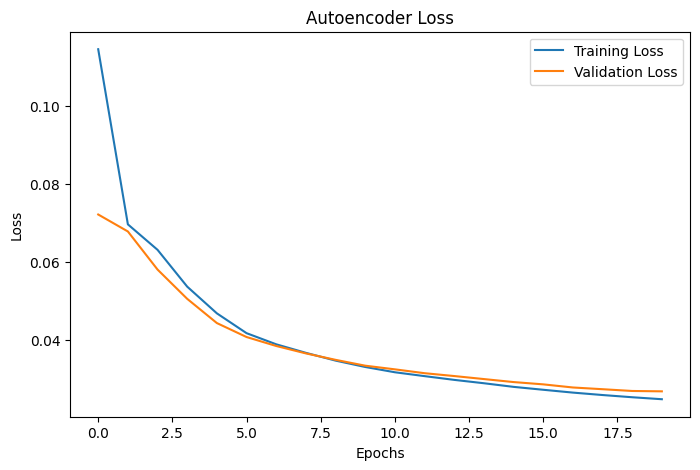

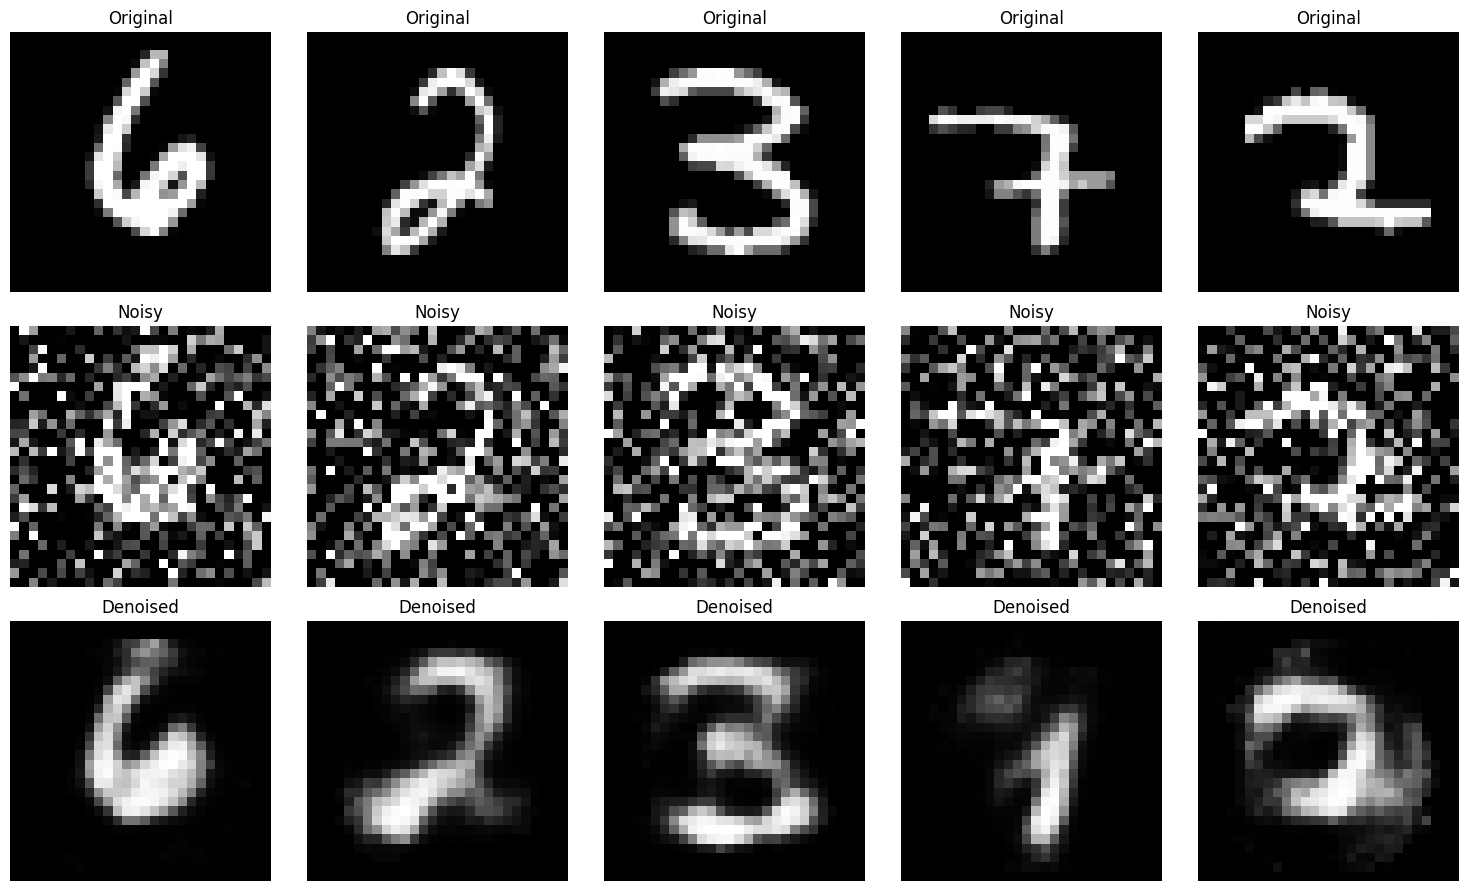

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv("mnist_test.csv")

print("Dataset shape:", df.shape)
print(df.head())

# ==============================
# 3. SEPARATE FEATURES AND LABEL
# ==============================
# First column is label, remaining 784 columns are pixels
X = df.iloc[:, 1:].values

# Normalize pixel values to [0,1]
X = X / 255.0

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# ==============================
# 5. ADD NOISE TO IMAGES
# ==============================
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Keep pixel values between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# ==============================
# 6. BUILD AUTOENCODER MODEL
# ==============================
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder
autoencoder = Model(input_img, decoded)

# ==============================
# 7. COMPILE MODEL
# ==============================
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# ==============================
# 8. TRAIN MODEL
# ==============================
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_noisy, X_test),
    verbose=1
)

# ==============================
# 9. DENOISE TEST IMAGES
# ==============================
denoised_images = autoencoder.predict(X_test_noisy)

# ==============================
# 10. PLOT LOSS GRAPH
# ==============================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==============================
# 11. SHOW ORIGINAL, NOISY, DENOISED
# ==============================
n = 5
plt.figure(figsize=(15, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()